# MicroFactual — End-to-End Feature Tour

This notebook exercises **every major feature** of MicroFactual on a *real* microbiome
dataset (Zeller et al. 2014 colorectal-cancer stool metagenomes), so it doubles as a
smoke test and a guided tour.

**What we cover**
1. Loading a real dataset with `MicrobiomeDataset`
2. Data exploration (`get_info`)
3. Microbiome-aware preprocessing transforms (abundance / prevalence / CLR)
4. sklearn-native usage — `Pipeline`, `cross_validate`, `GridSearchCV`
5. The one-liner `mf.classify()` API
6. Train / test evaluation with `MicrobiomeClassifier`
7. Visualization — ROC, confusion matrix, feature importance
8. **Counterfactual explanations** (the headline feature) via `DiCEExplainer`
9. Comparing algorithms (random forest vs. logistic regression)

> The dataset ships in `datasets/` (`abundance_crc.txt`, `metadata_crc.txt`).
> The counterfactual section requires the optional extra:
> `pip install 'microfactual[explainability]'`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import microfactual as mf

warnings.filterwarnings("ignore")  # keep the tour output clean
print("MicroFactual version:", mf.__version__)

MicroFactual version: 0.2.0


## 1. Load a real dataset

`MicrobiomeDataset.from_files` reads a species×samples abundance table and a metadata table, aligns them on the sample column, and gives sklearn-shaped `X` (samples×features) and encoded `y`.

In [2]:
ABUNDANCE = "../datasets/abundance_crc.txt"
METADATA = "../datasets/metadata_crc.txt"

dataset = mf.MicrobiomeDataset.from_files(
    abundance_file=ABUNDANCE,
    metadata_file=METADATA,
    target_column="Group",       # CRC vs Control
    sample_column="Sample ID",
)
print(dataset)
print("\nTarget classes:", dataset.target_names)

MicrobiomeDataset Summary:
  Samples: 141
  Features: 1753
  Target: Group (2 classes)
  Sparsity: 90.83%
  Preprocessing steps: 0

Target classes: ['CRC', 'Control']


## 2. Explore the data

`get_info()` returns dimensions, class balance, sparsity and read-depth statistics — useful sanity checks for compositional data.

In [3]:
info = dataset.get_info()
for key in [
    "n_samples", "n_features", "target_classes", "class_distribution",
    "sparsity", "mean_features_per_sample",
]:
    print(f"{key:>26}: {info[key]}")

X, y = dataset.X, dataset.y
print("\nX shape:", X.shape, "| y distribution:", dict(y.value_counts()))

                 n_samples: 141
                n_features: 1753
            target_classes: ['CRC', 'Control']
        class_distribution: {'Control': 88, 'CRC': 53}
                  sparsity: 0.9083273658530665
  mean_features_per_sample: 160.70212765957447

X shape: (141, 1753) | y distribution: {1: 88, 0: 53}


## 3. Microbiome-aware preprocessing

The transforms are plain sklearn transformers, usable standalone or in a `Pipeline`:
- **`AbundanceFilter`** — drop very-low-abundance features
- **`PrevalenceFilter`** — drop features present in too few samples
- **`CLRTransform`** — centered log-ratio transform for compositional data

In [4]:
from microfactual import AbundanceFilter, CLRTransform, PrevalenceFilter

step1 = AbundanceFilter(min_abundance=1e-6).fit_transform(X)
step2 = PrevalenceFilter(min_prevalence=0.01).fit_transform(step1)
step3 = CLRTransform().fit_transform(step2)

print(f"Raw features:            {X.shape[1]}")
print(f"After abundance filter:  {step1.shape[1]}")
print(f"After prevalence filter: {step2.shape[1]}")
print(f"After CLR (shape kept):  {step3.shape[1]}")
print("CLR output is real-valued (log-ratios):",
      f"min={np.asarray(step3).min():.2f}, max={np.asarray(step3).max():.2f}")

Raw features:            1753
After abundance filter:  322
After prevalence filter: 321
After CLR (shape kept):  321
CLR output is real-valued (log-ratios): min=-3.13, max=11.24


The `MicrobiomeDataset` also offers convenience methods that track a preprocessing history:

In [5]:
processed = dataset.filter_features(
    abundance_cutoff=1e-6, prevalence_cutoff=0.01, inplace=False
)
processed = processed.clr_transform(inplace=False)
print(processed)
for step in processed._preprocessing_history:
    print(" -", step["step"], step.get("parameters", {}))

MicrobiomeDataset Summary:
  Samples: 141
  Features: 321
  Target: Group (2 classes)
  Sparsity: 0.00%
  Preprocessing steps: 2
 - filter_features {'abundance_cutoff': 1e-06, 'prevalence_cutoff': 0.01}
 - clr_transform {'log_n0': 1e-06}


## 4. sklearn-native usage

`MicrobiomeClassifier` is a drop-in sklearn estimator (`preprocessing="auto"` bundles the three transforms above), so all of sklearn's model-selection machinery works.

In [6]:
from sklearn.model_selection import cross_validate

clf = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing="auto")

cv = cross_validate(
    clf, X, y, cv=5,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False,
)
for metric in ["test_accuracy", "test_f1", "test_roc_auc"]:
    print(f"{metric:>16}: {cv[metric].mean():.3f} ± {cv[metric].std():.3f}")

   test_accuracy: 0.751 ± 0.061
         test_f1: 0.818 ± 0.043
    test_roc_auc: 0.852 ± 0.071


In [7]:
# GridSearchCV can tune both the wrapper's own params and keyword args
# forwarded to the underlying classifier (e.g. n_estimators, max_depth).
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    mf.MicrobiomeClassifier(algorithm="random_forest"),
    param_grid={"n_estimators": [50, 100], "max_depth": [None, 5]},
    cv=3,
    scoring="roc_auc",
)
grid.fit(X, y)
print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

Best params: {'max_depth': None, 'n_estimators': 50}
Best CV ROC-AUC: 0.818


## 5. One-liner API

`mf.classify()` wraps load → preprocess → cross-validate → fit into a single call, straight from file paths.

In [8]:
results = mf.classify(
    ABUNDANCE, METADATA,
    target_column="Group",
    sample_column="Sample ID",
    algorithm="random_forest",
    cv_folds=5,
)
print("Returned keys:", list(results))
print("CV scores:")
for k, v in results["cv_scores"].items():
    print(f"  {k:>18}: {v:.3f}")

Returned keys: ['model', 'dataset', 'cv_scores']
CV scores:
            fit_time: 0.072
          score_time: 0.005
       test_accuracy: 0.751
      train_accuracy: 1.000
             test_f1: 0.818
            train_f1: 1.000
        test_roc_auc: 0.852
       train_roc_auc: 1.000


## 6. Train / test evaluation

A held-out split to produce predictions we can visualize below.

In [9]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing="auto")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=dataset.target_names))

              precision    recall  f1-score   support

         CRC       0.70      0.44      0.54        16
     Control       0.73      0.89      0.80        27

    accuracy                           0.72        43
   macro avg       0.71      0.66      0.67        43
weighted avg       0.72      0.72      0.70        43



## 7. Visualization

Built-in plotting helpers return matplotlib figures.

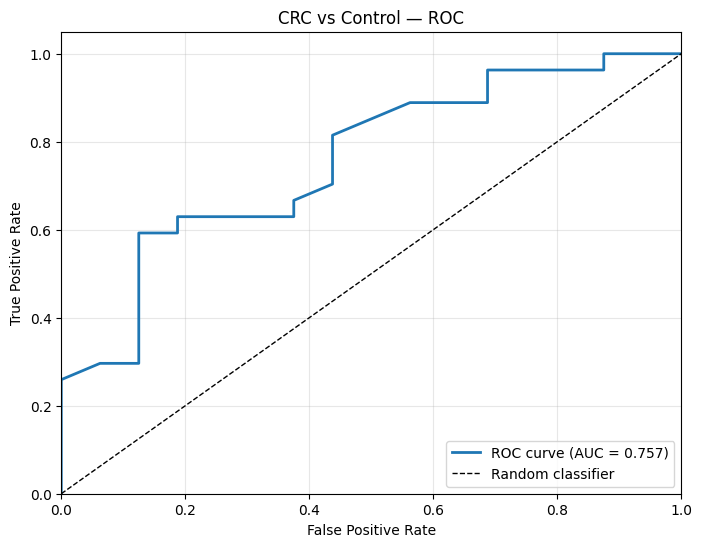

In [10]:
fig = mf.plot_roc(y_test, y_proba, title="CRC vs Control — ROC")
plt.show()

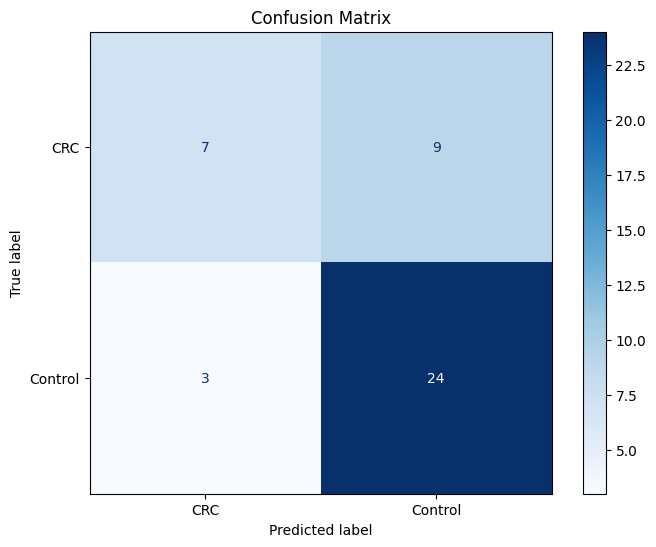

In [11]:
fig = mf.plot_confusion_matrix(
    y_test, y_pred, labels=dataset.target_names, title="Confusion Matrix"
)
plt.show()

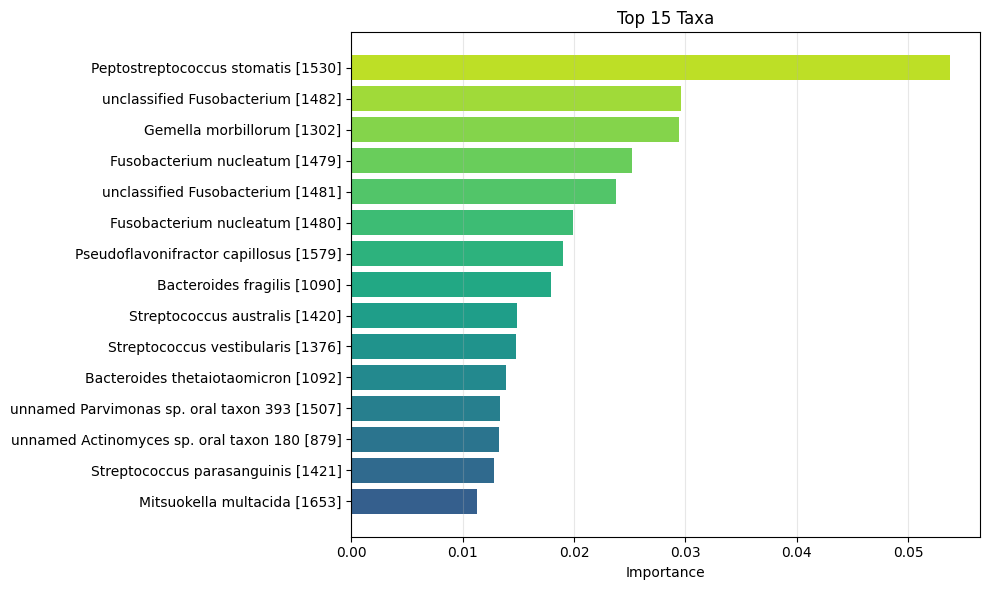

In [12]:
# Map importances back to the feature names that survived preprocessing
kept = model.pipeline_[:-1].get_feature_names_out()
importances = pd.Series(model.feature_importances_, index=kept)
fig = mf.plot_feature_importance(importances, top_n=15, title="Top 15 Taxa")
plt.show()

## 8. Counterfactual explanations (headline feature)

The core question MicroFactual is built to answer: *what minimal change in taxa
abundance would flip this sample's prediction?* We fit a model on CLR-transformed
features, then ask `DiCEExplainer` for counterfactuals on a single test sample.

> Requires the `explainability` extra. If it isn't installed, this section prints a
> hint and is skipped rather than erroring.

In [13]:
# Work in the CLR-transformed feature space so DiCE perturbs the model's actual inputs.
X_clr = pd.DataFrame(
    CLRTransform().fit_transform(
        PrevalenceFilter(min_prevalence=0.01).fit_transform(
            AbundanceFilter(min_abundance=1e-6).fit_transform(X)
        )
    )
)
X_clr.columns = [f"f{i}" for i in range(X_clr.shape[1])]  # DiCE-friendly names

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clr, y, test_size=0.3, random_state=42, stratify=y
)

# A plain classifier on the already-transformed space (preprocessing=None)
cf_model = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing=None)
cf_model.fit(Xc_train, yc_train)
print("Counterfactual model trained on", Xc_train.shape[1], "CLR features")

Counterfactual model trained on 321 CLR features


In [14]:
try:
    explainer = mf.DiCEExplainer(
        model=cf_model,
        background_data=Xc_train,
        target_column="Group",
        target_data=yc_train,
    )
    query = Xc_test.iloc[[0]]
    print("Prediction for query sample:",
          dataset.target_names[int(cf_model.predict(query)[0])])

    cf = explainer.explain(query, total_CFs=3, desired_class="opposite")
    cf.visualize_as_dataframe(show_only_changes=True)
except ImportError as e:
    print("Counterfactual section skipped —", e)

Prediction for query sample: Control


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.43it/s]

100%|██████████| 1/1 [00:00<00:00,  2.43it/s]

Query instance (original outcome : 1)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f312,f313,f314,f315,f316,f317,f318,f319,f320,Group
0,-1.651685,1.607858,4.067077,2.031572,-1.651685,0.886213,-1.651685,-1.651685,-1.651685,-1.651685,...,1.524223,-1.651685,8.398719,-1.651685,1.08387,-1.651685,-1.651685,1.999448,-1.651685,1



Diverse Counterfactual set (new outcome: 0)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f312,f313,f314,f315,f316,f317,f318,f319,f320,Group
0,-1.658748388,3.07791972,6.81216097,6.5858531,8.66979694,-1.658748388,-1.658748388,-1.65874839,-1.658748388,-0.698746443,...,1.30955088,-1.658748388,5.421412468,-1.6587483883,2.022823334,3.41038799,-1.658748388,0.239433646,-1.65874839,0.0
0,-1.687136173,2.03709078,5.4041996,2.698209286,7.40868378,-1.687136173,-1.687136173,-1.68713617,-1.687136173,-1.687136173,...,0.76798427,-1.687136173,6.975078106,1.6736824512,8.974164963,4.53500175,4.277351379,-1.687136173,-1.68713617,0.0
0,-1.464404345,-1.46440434,5.00017118,1.536356211,-1.46440434,-1.464404345,1.242063642,-1.46440434,-1.464404345,-1.464404345,...,-1.46440434,-1.464404345,-1.464404345,4.096763134,-1.464404345,-1.46440434,-1.464404345,-1.464404345,-1.46440434,0.0


## 9. Compare algorithms

Same interface, different estimator.

In [15]:
from sklearn.model_selection import cross_val_score

for algo in ["random_forest", "logistic"]:
    scores = cross_val_score(
        mf.MicrobiomeClassifier(algorithm=algo, preprocessing="auto"),
        X, y, cv=5, scoring="roc_auc",
    )
    print(f"{algo:>14}: ROC-AUC {scores.mean():.3f} ± {scores.std():.3f}")

 random_forest: ROC-AUC 0.852 ± 0.071
      logistic: ROC-AUC 0.780 ± 0.108


## Summary

We exercised the full public surface end-to-end on a real CRC dataset:
`MicrobiomeDataset`, the preprocessing transforms, sklearn interop
(`Pipeline`/`cross_validate`/`GridSearchCV`), the `mf.classify()` one-liner,
`MicrobiomeClassifier` train/predict, the visualization helpers, and
`DiCEExplainer` counterfactuals.

If every cell above ran without error, the library is healthy end-to-end.